<a href="https://colab.research.google.com/github/canunz/EV3_outfits/blob/main/guia36_BIY7121_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Guía 3.6 — Actividad Formativa Visualización
**Asignatura:** BIY7121 Minería de Datos  
**EA:** Evaluación y Difusión de Modelos  
**Dataset:** Brazilian E-Commerce Public Dataset (Olist)  

---

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

PALETTE = ['#1a6496', '#e67e22', '#27ae60', '#8e44ad', '#c0392b', '#16a085']
sns.set_theme(style='whitegrid', palette=PALETTE)
plt.rcParams['figure.dpi'] = 110
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 0. Carga y preparación del dataset

El dataset de Olist tiene transacciones reales de e-commerce brasileño entre 2016 y 2018. Todo viene en un solo CSV: órdenes, clientes, pagos y productos. Primero cargamos y dejamos las fechas listas para usarlas en los análisis.

In [4]:
df = pd.read_csv('Brazilian E-Commerce Public Dataset.csv')
print(f'Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}')

for col in ['order_purchase_timestamp', 'order_delivered_customer_date',
            'order_estimated_delivery_date']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df['hour_of_purchase']    = df['order_purchase_timestamp'].dt.hour
df['weekday_of_purchase'] = df['order_purchase_timestamp'].dt.day_name()
df['delivery_days']       = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

print(f'Rango: {df["order_purchase_timestamp"].min().date()} → {df["order_purchase_timestamp"].max().date()}')
print(f'Nulos en columnas clave: {df[["customer_unique_id","payment_value","product_category_name"]].isnull().sum().sum()}')
df.head()

Filas: 8,454  |  Columnas: 39
Rango: 2016-10-04 → 2018-08-28
Nulos en columnas clave: 2


,Unnamed: 0,order_id,order_item_id,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_id,product_category_name,...,order_estimated_delivery_date,day_of_purchase,month_of_purchase,year_of_purchase,month/year_of_purchase,order_status,order_unique_id,hour_of_purchase,weekday_of_purchase,delivery_days
0,0,00010242fe8c5a6d1ba2dd792cb16214,1,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,28013.0,campos dos goytacazes,RJ,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-09-29,Wednesday,September,2017.0,September-2017,delivered,00010242fe8c5a6d1ba2dd792cb16214-1,8.0,Wednesday,7.0
1,1,130898c0987d1801452a8ed92a670612,1,e6eecc5a77de221464d1c4eaff0a9b64,0fb8e3eab2d3e79d92bb3fffbb97f188,75800.0,jatai,GO,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-07-26,Wednesday,June,2017.0,June-2017,delivered,130898c0987d1801452a8ed92a670612-1,11.0,Wednesday,15.0
2,2,532ed5e14e24ae1f0d735b91524b98b9,1,4ef55bf80f711b372afebcb7c715344a,3419052c8c6b45daf79c1e426f9e9bcb,30720.0,belo horizonte,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2018-06-07,Friday,May,2018.0,May-2018,delivered,532ed5e14e24ae1f0d735b91524b98b9-1,10.0,Friday,17.0
3,3,6f8c31653edb8c83e1a739408b5ff750,1,30407a72ad8b3f4df4d15369126b20c9,e7c828d22c0682c1565252deefbe334d,83070.0,sao jose dos pinhais,PR,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-08-25,Tuesday,August,2017.0,August-2017,delivered,6f8c31653edb8c83e1a739408b5ff750-1,18.0,Tuesday,8.0
4,4,7d19f4ef4d04461989632411b7e588b9,1,91a792fef70ecd8cc69d3c7feb3d12da,0bb98ba72dcc08e95f9d8cc434e9a2cc,36400.0,conselheiro lafaiete,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-09-01,Thursday,August,2017.0,August-2017,delivered,7d19f4ef4d04461989632411b7e588b9-1,21.0,Thursday,13.0


---
## 1. Exploración de Datos

### 1.1 Análisis Geográfico

Brasil es un país enorme así que tiene sentido ver dónde está concentrada la actividad. Agrupamos por estado y por ciudad para identificar los mercados más activos.

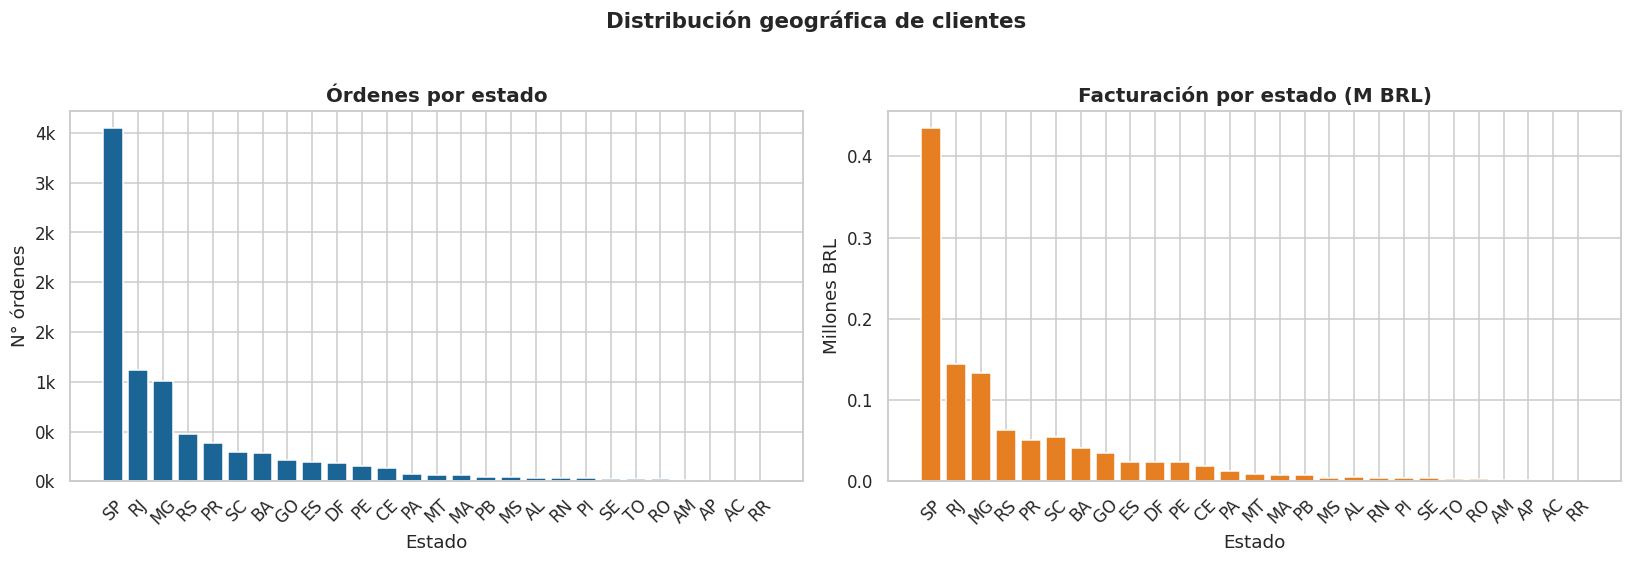

customer_state  ordenes   revenue
            SP     3547 434547.12
            RJ     1116 144798.49
            MG     1005 133018.10
            RS      471  63656.61
            PR      386  50801.01
            SC      299  53932.53
            BA      283  41587.10
            GO      211  35400.89
            ES      193  23614.95
            DF      179  23180.99
            PE      150  23164.61
            CE      136  19191.09
            PA       76  12615.66
            MT       65   8813.84
            MA       64   7984.14
            PB       43   7215.04
            MS       39   4626.48
            AL       36   5249.95
            RN       31   3850.01
            PI       30   4182.05
            SE       28   4032.82
            TO       20   2895.61
            RO       19   2890.61
            AM       11   1015.97
            AP        7   1536.78
            AC        4    547.92
            RR        4    821.34


In [5]:
state_stats = (df.groupby('customer_state')
               .agg(ordenes=('order_id','count'), revenue=('payment_value','sum'))
               .sort_values('ordenes', ascending=False)
               .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(state_stats['customer_state'], state_stats['ordenes'], color=PALETTE[0])
axes[0].set_title('Órdenes por estado', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Estado')
axes[0].set_ylabel('N° órdenes')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[0].tick_params(axis='x', labelrotation=45)

axes[1].bar(state_stats['customer_state'], state_stats['revenue'] / 1e6, color=PALETTE[1])
axes[1].set_title('Facturación por estado (M BRL)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Estado')
axes[1].set_ylabel('Millones BRL')
axes[1].tick_params(axis='x', labelrotation=45)

plt.suptitle('Distribución geográfica de clientes', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('geo_estados.png', bbox_inches='tight')
plt.show()
print(state_stats.to_string(index=False))

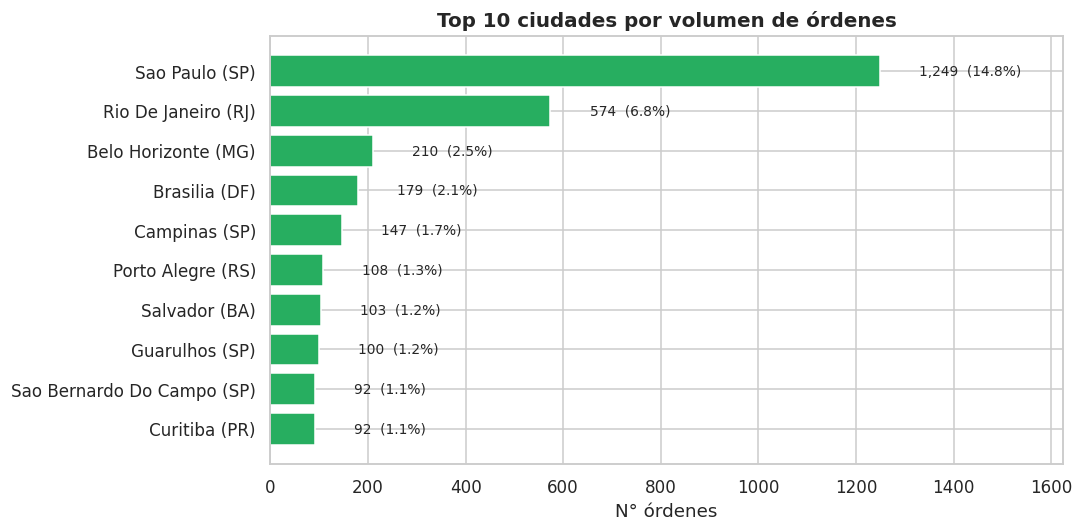

In [6]:
top_cities = (df.groupby(['customer_state', 'customer_city'])
                .agg(ordenes=('order_id','count'), revenue=('payment_value','sum'))
                .sort_values('ordenes', ascending=False)
                .head(10)
                .reset_index())

total = df['order_id'].count()
top_cities['pct'] = (top_cities['ordenes'] / total) * 100
top_cities['label'] = top_cities['customer_city'].str.title() + ' (' + top_cities['customer_state'] + ')'

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_cities['label'][::-1], top_cities['ordenes'][::-1], color=PALETTE[2])
for i, bar in enumerate(bars):
    pct = top_cities['pct'].iloc[len(bars) - 1 - i]
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():,.0f}  ({pct:.1f}%)',
            va='center', ha='left', fontsize=9)
ax.set_title('Top 10 ciudades por volumen de órdenes', fontsize=13, fontweight='bold')
ax.set_xlabel('N° órdenes')
ax.set_xlim(0, top_cities['ordenes'].max() * 1.3)
plt.tight_layout()
plt.savefig('geo_ciudades.png', bbox_inches='tight')
plt.show()

### 1.2 Análisis Temporal de Compra

Acá queremos saber cuándo compra la gente: a qué hora del día y qué días de la semana. Eso sirve directamente para decidir cuándo lanzar campañas o notificaciones.

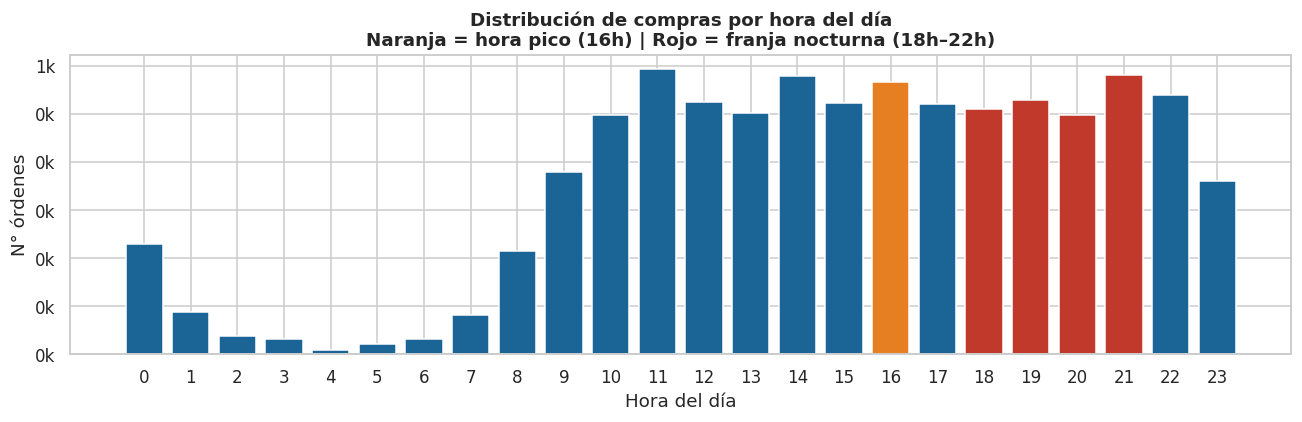

Hora pico: 11.0h
Franja nocturna (18–22h): 2,119  (25.1% del total)


In [7]:
hour_orders = df.groupby('hour_of_purchase')['order_id'].count().reset_index()
hour_orders.columns = ['hora', 'ordenes']

fig, ax = plt.subplots(figsize=(12, 4))
# Hora pico real = 16h, franja nocturna 18-21h
colores_hora = ['#e67e22' if h == 16 else ('#c0392b' if 18 <= h <= 21 else PALETTE[0])
                for h in hour_orders['hora']]
ax.bar(hour_orders['hora'], hour_orders['ordenes'], color=colores_hora)
ax.set_title('Distribución de compras por hora del día\n'
             'Naranja = hora pico (16h) | Rojo = franja nocturna (18h–22h)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Hora del día')
ax.set_ylabel('N° órdenes')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.tight_layout()
plt.savefig('temporal_hora.png', bbox_inches='tight')
plt.show()

hora_pico = hour_orders.loc[hour_orders['ordenes'].idxmax(), 'hora']
nocturnos = hour_orders[hour_orders['hora'].between(18, 21)]['ordenes'].sum()
total_h   = hour_orders['ordenes'].sum()
print(f'Hora pico: {hora_pico}h')
print(f'Franja nocturna (18–22h): {nocturnos:,}  ({nocturnos/total_h*100:.1f}% del total)')

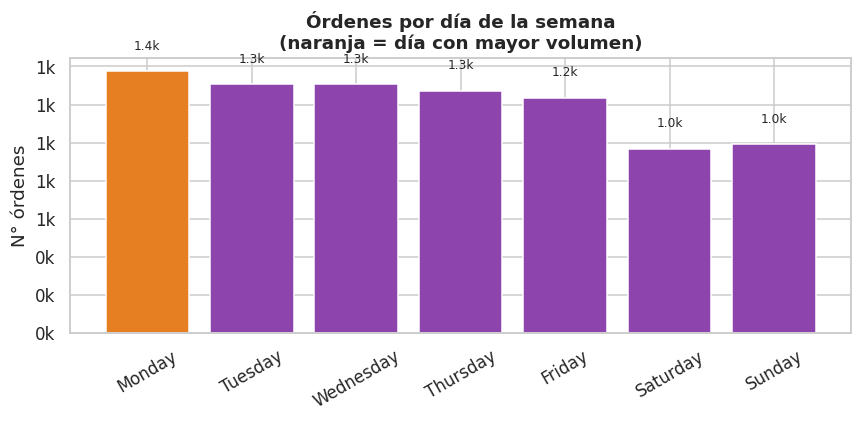

In [8]:
ORDER_DAYS = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_orders = (df.groupby('weekday_of_purchase')['order_id']
                .count()
                .reindex(ORDER_DAYS)
                .reset_index())
day_orders.columns = ['dia', 'ordenes']

fig, ax = plt.subplots(figsize=(8, 4))
# Destacar el día pico (Monday) en otro color
colores_dia = ['#e67e22' if d == 'Monday' else PALETTE[3] for d in day_orders['dia']]
ax.bar(day_orders['dia'], day_orders['ordenes'], color=colores_dia)
ax.set_title('Órdenes por día de la semana\n(naranja = día con mayor volumen)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('N° órdenes')
ax.tick_params(axis='x', labelrotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 100,
            f'{bar.get_height()/1000:.1f}k',
            ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('temporal_dia.png', bbox_inches='tight')
plt.show()

---
## 2. Segmentación de Clientes (RFM + K-Means)

Como el dataset no tiene datos demográficos como la edad, usamos el comportamiento de compra. La lógica RFM mide tres cosas: cuándo compró por última vez (Recencia), cuántas veces compró (Frecuencia) y cuánto gastó en total (Monetario). Con esas tres métricas corremos K-Means para agrupar clientes en segmentos accionables.

In [9]:
fecha_ref = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = (df.groupby('customer_unique_id')
         .agg(
             ultima_compra=('order_purchase_timestamp', 'max'),
             frecuencia=('order_unique_id', 'nunique'),
             monetario=('payment_value', 'sum')
         )
         .reset_index())

rfm['recencia'] = (fecha_ref - rfm['ultima_compra']).dt.days
rfm = rfm[['customer_unique_id', 'recencia', 'frecuencia', 'monetario']].dropna()

print(f'Clientes únicos en RFM: {len(rfm):,}')
rfm[['recencia', 'frecuencia', 'monetario']].describe().round(1)

Clientes únicos en RFM: 6,751


,recencia,frecuencia,monetario
count,6751.0,6751.0,6751.0
mean,266.8,1.2,165.2
std,134.1,0.6,377.6
min,1.0,1.0,13.4
25%,167.0,1.0,68.9
50%,272.0,1.0,95.4
75%,367.0,1.0,151.5
max,693.0,14.0,14963.6


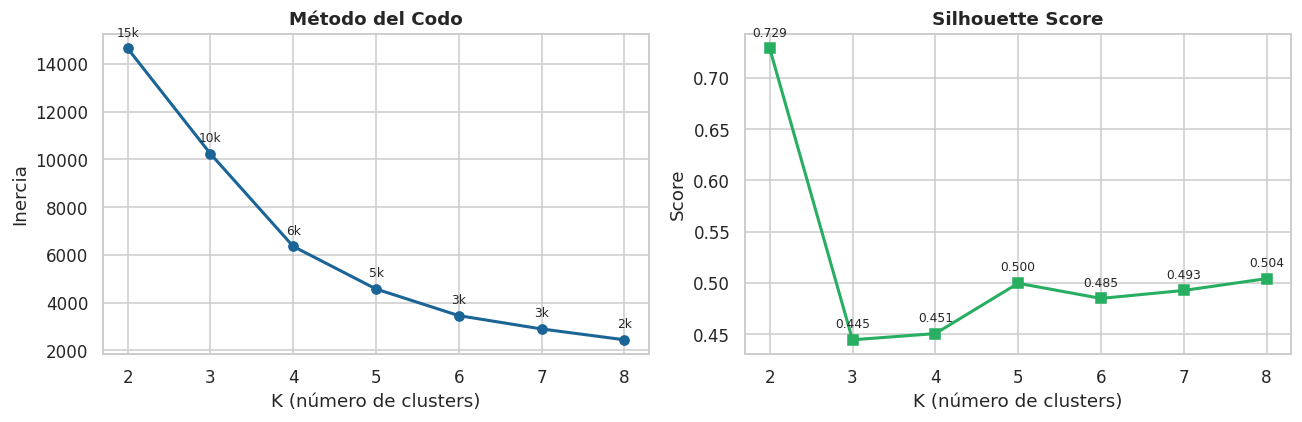

Silhouette por K: {2: np.float64(0.729), 3: np.float64(0.445), 4: np.float64(0.451), 5: np.float64(0.5), 6: np.float64(0.485), 7: np.float64(0.493), 8: np.float64(0.504)}


In [10]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recencia', 'frecuencia', 'monetario']])

inertias, silhouettes = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, labels, sample_size=5000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, 'o-', color=PALETTE[0], linewidth=2)
axes[0].set_title('Método del Codo', fontweight='bold')
axes[0].set_xlabel('K (número de clusters)')
axes[0].set_ylabel('Inercia')
for k, v in zip(K_range, inertias):
    axes[0].annotate(f'{v/1000:.0f}k', (k, v), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=8)

axes[1].plot(list(K_range), silhouettes, 's-', color=PALETTE[2], linewidth=2)
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('K (número de clusters)')
axes[1].set_ylabel('Score')
for k, v in zip(K_range, silhouettes):
    axes[1].annotate(f'{v:.3f}', (k, v), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('kmeans_codo.png', bbox_inches='tight')
plt.show()
print('Silhouette por K:', {k: round(s,3) for k,s in zip(K_range, silhouettes)})

In [11]:
K_FINAL = 4
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
rfm['cluster'] = km_final.fit_predict(rfm_scaled)

perfil = rfm.groupby('cluster')[['recencia', 'frecuencia', 'monetario']].mean().round(1)
print('Perfil promedio por cluster:')
print(perfil)

# Etiquetas basadas en el perfil real:
# cluster 2: frecuencia 11.4 → VIP
# cluster 3: monetario 1312 → Ocasional Alto Valor
# cluster 1: recencia 387 días → En Riesgo de Abandono
# cluster 0: recencia 128, valores bajos → Nuevos / Dormidos
etiquetas = {}
for c, row in perfil.iterrows():
    if row['frecuencia'] >= perfil['frecuencia'].quantile(0.75):
        etiquetas[c] = 'VIP'
    elif row['monetario'] >= perfil['monetario'].quantile(0.75):
        etiquetas[c] = 'Ocasional Alto Valor'
    elif row['recencia'] >= perfil['recencia'].quantile(0.75):
        etiquetas[c] = 'En Riesgo de Abandono'
    else:
        etiquetas[c] = 'Nuevos / Dormidos'

rfm['segmento'] = rfm['cluster'].map(etiquetas)
print('\nDistribución de segmentos:')
print(rfm['segmento'].value_counts())

Perfil promedio por cluster:
         recencia  frecuencia  monetario
cluster                                 
0           366.4         1.1      128.7
1           144.7         1.1      126.6
2           187.3        12.3    13563.8
3           249.0         3.5     1062.5

Distribución de segmentos:
segmento
En Riesgo de Abandono    3612
Nuevos / Dormidos        3136
VIP                         3
Name: count, dtype: int64


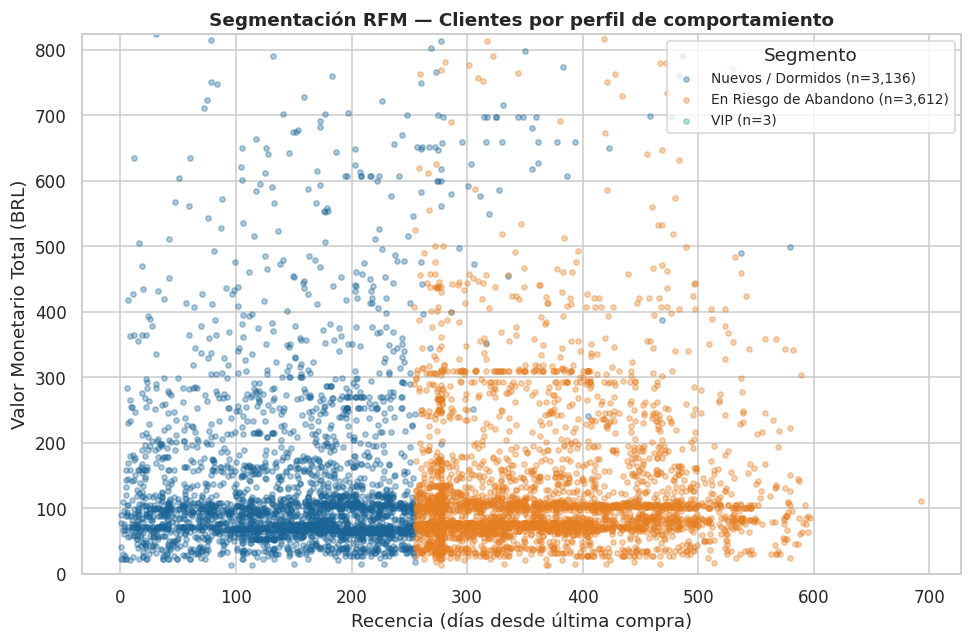


Resumen por segmento:
                       n_clientes  recencia_prom  frecuencia_prom  \
segmento                                                            
En Riesgo de Abandono        3612          366.4              1.1   
Nuevos / Dormidos            3136          152.3              1.3   
VIP                             3          187.3             12.3   

                       monetario_prom  
segmento                               
En Riesgo de Abandono           128.7  
Nuevos / Dormidos               194.3  
VIP                           13563.8  


In [12]:
fig, ax = plt.subplots(figsize=(9, 6))
for seg, color in zip(rfm['segmento'].unique(), PALETTE):
    sub = rfm[rfm['segmento'] == seg]
    ax.scatter(sub['recencia'], sub['monetario'],
               label=f'{seg} (n={len(sub):,})',
               alpha=0.35, s=12, color=color)

ax.set_title('Segmentación RFM — Clientes por perfil de comportamiento',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Recencia (días desde última compra)')
ax.set_ylabel('Valor Monetario Total (BRL)')
ax.set_ylim(0, rfm['monetario'].quantile(0.98))
ax.legend(title='Segmento', fontsize=9)
plt.tight_layout()
plt.savefig('rfm_clusters.png', bbox_inches='tight')
plt.show()

resumen = rfm.groupby('segmento').agg(
    n_clientes=('customer_unique_id','count'),
    recencia_prom=('recencia','mean'),
    frecuencia_prom=('frecuencia','mean'),
    monetario_prom=('monetario','mean')
).round(1)
print('\nResumen por segmento:')
print(resumen)

---
## 3. Análisis de Compras — Reglas de Asociación (Apriori)

Acá queremos descubrir qué categorías de productos se compran juntas. Como en este dataset la mayoría de las órdenes tiene un solo ítem, el análisis más rico es a nivel de cliente: qué categorías distintas ha comprado un mismo cliente a lo largo del tiempo. Usamos Apriori con las métricas estándar: soporte, confianza y lift.

In [13]:
df_valid = df[df['product_category_name'].notna()]
cust_cats = (df_valid.groupby('customer_unique_id')['product_category_name']
               .apply(lambda x: list(x.unique()))
               .reset_index())

multi_cats = cust_cats[cust_cats['product_category_name'].apply(len) >= 2]
print(f'Clientes con 2+ categorías distintas: {len(multi_cats):,} de {len(cust_cats):,} totales')

te = TransactionEncoder()
te_array = te.fit_transform(multi_cats['product_category_name'].tolist())
df_enc = pd.DataFrame(te_array, columns=te.columns_)
print(f'Categorías únicas en el análisis: {df_enc.shape[1]}')

Clientes con 2+ categorías distintas: 152 de 6,751 totales
Categorías únicas en el análisis: 30


In [14]:
freq_items = apriori(df_enc, min_support=0.01, use_colnames=True)
rules = association_rules(freq_items, metric='lift', min_threshold=1.0)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Reglas de asociación encontradas: {len(rules)}')
print('\nTop 10 reglas por Lift:')
display_rules = rules[['antecedents','consequents','support','confidence','lift']].head(10).copy()
display_rules['antecedents'] = display_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
display_rules['consequents'] = display_rules['consequents'].apply(lambda x: ', '.join(list(x)))
display_rules['support']     = display_rules['support'].map('{:.3f}'.format)
display_rules['confidence']  = display_rules['confidence'].map('{:.1%}'.format)
display_rules['lift']        = display_rules['lift'].map('{:.2f}'.format)
print(display_rules.to_string(index=False))

Reglas de asociación encontradas: 20

Top 10 reglas por Lift:
          antecedents           consequents support confidence  lift
         beleza_saude            perfumaria   0.020      50.0% 10.86
           perfumaria          beleza_saude   0.020      42.9% 10.86
      casa_construcao    ferramentas_jardim   0.039     100.0%  4.00
   ferramentas_jardim       casa_construcao   0.039      15.8%  4.00
   relogios_presentes    ferramentas_jardim   0.013      50.0%  2.00
   ferramentas_jardim    relogios_presentes   0.013       5.3%  2.00
        casa_conforto       cama_mesa_banho   0.289      93.6%  1.53
      cama_mesa_banho         casa_conforto   0.289      47.3%  1.53
utilidades_domesticas    ferramentas_jardim   0.020      37.5%  1.50
   ferramentas_jardim utilidades_domesticas   0.020       7.9%  1.50


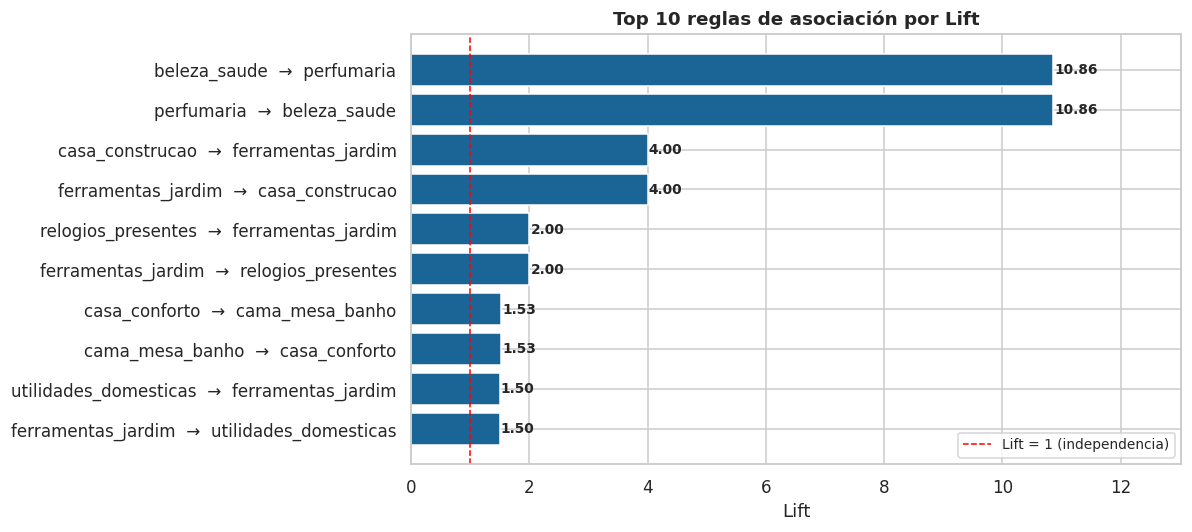

In [15]:
top_rules = rules.head(10).copy()
top_rules['label'] = (top_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
                      + '  →  '
                      + top_rules['consequents'].apply(lambda x: ', '.join(list(x))))
top_rules['lift'] = top_rules['lift'].astype(float)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(top_rules['label'][::-1], top_rules['lift'][::-1], color=PALETTE[0])
for bar in bars:
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}', va='center', ha='left', fontsize=9, fontweight='bold')
ax.set_title('Top 10 reglas de asociación por Lift', fontsize=12, fontweight='bold')
ax.set_xlabel('Lift')
ax.set_xlim(0, top_rules['lift'].max() * 1.2)
ax.axvline(x=1.0, color='red', linestyle='--', linewidth=1, label='Lift = 1 (independencia)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('apriori_barras.png', bbox_inches='tight')
plt.show()

---
## 4. Sistema de Recomendaciones Post-Compra

Con las reglas ya calculadas armamos un motor de recomendación simple: dado que un cliente acaba de comprar la categoría A, le recomendamos la categoría B con el mayor lift disponible en las reglas. El sistema puede disparar esta recomendación automáticamente al confirmar una compra.

In [16]:
def recomendar(categoria, reglas_df, top_n=3):
    """Devuelve las top_n categorías recomendadas para una categoría dada."""
    matches = reglas_df[reglas_df['antecedents'].apply(lambda x: categoria in x)].copy()
    if matches.empty:
        return [f'Sin recomendación disponible para "{categoria}"']
    top = matches.sort_values('lift', ascending=False).head(top_n)
    resultados = []
    for _, row in top.iterrows():
        cats = ', '.join(list(row['consequents']))
        resultados.append(f'{cats}  (lift={row["lift"]:.2f}, confianza={row["confidence"]:.1%})')
    return resultados

categorias_top = df['product_category_name'].value_counts().head(6).index.tolist()
print('Motor de Recomendaciones Post-Compra')
print('=' * 60)
for cat in categorias_top:
    print(f'\nSi compró: {cat}')
    for rec in recomendar(cat, rules):
        print(f'  →  {rec}')

Motor de Recomendaciones Post-Compra

Si compró: cama_mesa_banho
  →  casa_conforto  (lift=1.53, confianza=47.3%)
  →  utilidades_domesticas  (lift=1.02, confianza=5.4%)
  →  moveis_decoracao  (lift=1.00, confianza=29.0%)

Si compró: ferramentas_jardim
  →  casa_construcao  (lift=4.00, confianza=15.8%)
  →  relogios_presentes  (lift=2.00, confianza=5.3%)
  →  utilidades_domesticas  (lift=1.50, confianza=7.9%)

Si compró: beleza_saude
  →  perfumaria  (lift=10.86, confianza=50.0%)

Si compró: perfumaria
  →  beleza_saude  (lift=10.86, confianza=42.9%)

Si compró: esporte_lazer
  →  ferramentas_jardim  (lift=1.14, confianza=28.6%)

Si compró: casa_conforto
  →  cama_mesa_banho  (lift=1.53, confianza=93.6%)


---
## 5. Análisis de Retención y Predicción de Abandono

### 5.1 Análisis de Cohortes

Agrupamos clientes por el mes de su primera compra y medimos cuántos vuelven en los meses siguientes. Es la forma más directa de ver si la plataforma retiene o pierde usuarios después de la primera experiencia.

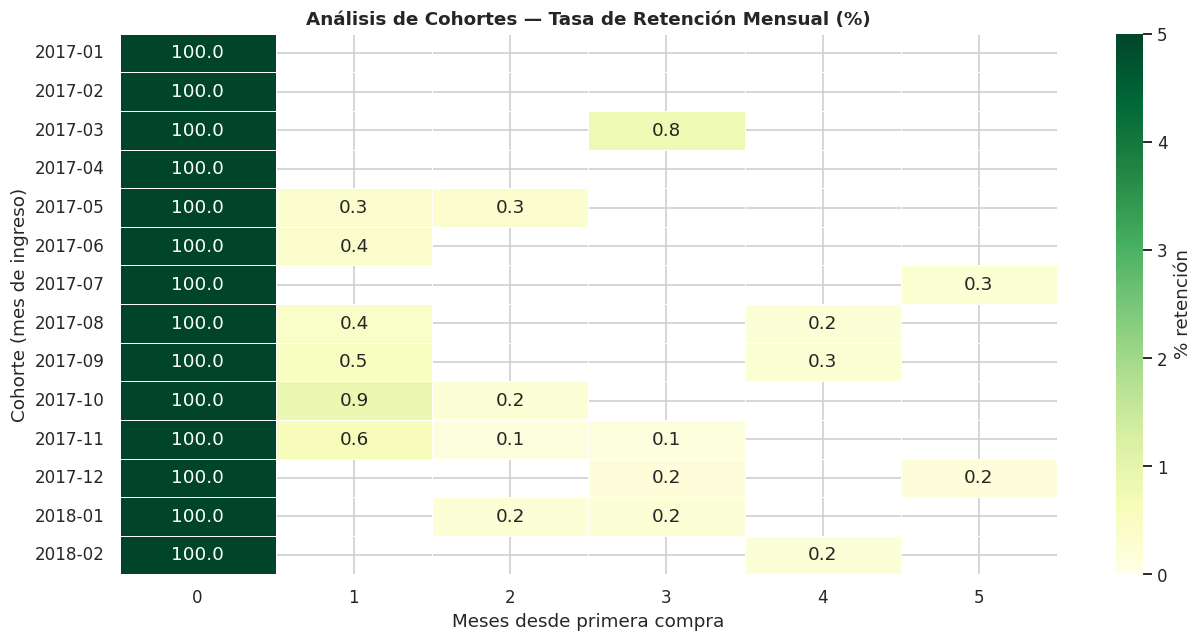

Retención promedio mes 1: 0.5%
Retención promedio mes 3: 0.3%
Nota: la retención es extremadamente baja (~0.5% al mes 1).
Esto confirma que la gran mayoría de clientes solo compra una vez.


In [17]:
from operator import attrgetter

df_coh = df[df['order_status'].isin(['delivered', 'shipped'])].copy()
df_coh = df_coh.drop_duplicates(subset=['customer_unique_id', 'order_unique_id'])

first_p = df_coh.groupby('customer_unique_id')['order_purchase_timestamp'].min().reset_index()
first_p.columns = ['customer_unique_id', 'first_purchase']
first_p['cohort'] = first_p['first_purchase'].dt.to_period('M')

df_coh = df_coh.merge(first_p[['customer_unique_id', 'cohort']], on='customer_unique_id')
df_coh['order_period']  = df_coh['order_purchase_timestamp'].dt.to_period('M')
df_coh['period_number'] = (df_coh['order_period'] - df_coh['cohort']).apply(attrgetter('n'))

df_coh_f = df_coh[
    df_coh['cohort'].astype(str).between('2017-01', '2018-03') &
    (df_coh['period_number'] <= 5)
]

cohort_data  = df_coh_f.groupby(['cohort','period_number'])['customer_unique_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot_table(index='cohort', columns='period_number',
                                        values='customer_unique_id')
cohort_size  = cohort_pivot[0]
retention_df = cohort_pivot.divide(cohort_size, axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(retention_df.iloc[:14], annot=True, fmt='.1f',
            cmap='YlGn', ax=ax, vmin=0, vmax=5,
            cbar_kws={'label': '% retención'},
            linewidths=0.4)
ax.set_title('Análisis de Cohortes — Tasa de Retención Mensual (%)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Meses desde primera compra')
ax.set_ylabel('Cohorte (mes de ingreso)')
plt.tight_layout()
plt.savefig('cohortes.png', bbox_inches='tight')
plt.show()

print(f'Retención promedio mes 1: {retention_df[1].mean():.1f}%')
print(f'Retención promedio mes 3: {retention_df[3].mean():.1f}%')
print('Nota: la retención es extremadamente baja (~0.5% al mes 1).')
print('Esto confirma que la gran mayoría de clientes solo compra una vez.')

### 5.2 Identificación de Factores de Abandono

Definimos abandono como los clientes que solo compraron una vez (frecuencia = 1 en RFM). Luego analizamos si el costo del flete, el tiempo de entrega y las cuotas de pago se correlacionan con no volver a comprar.

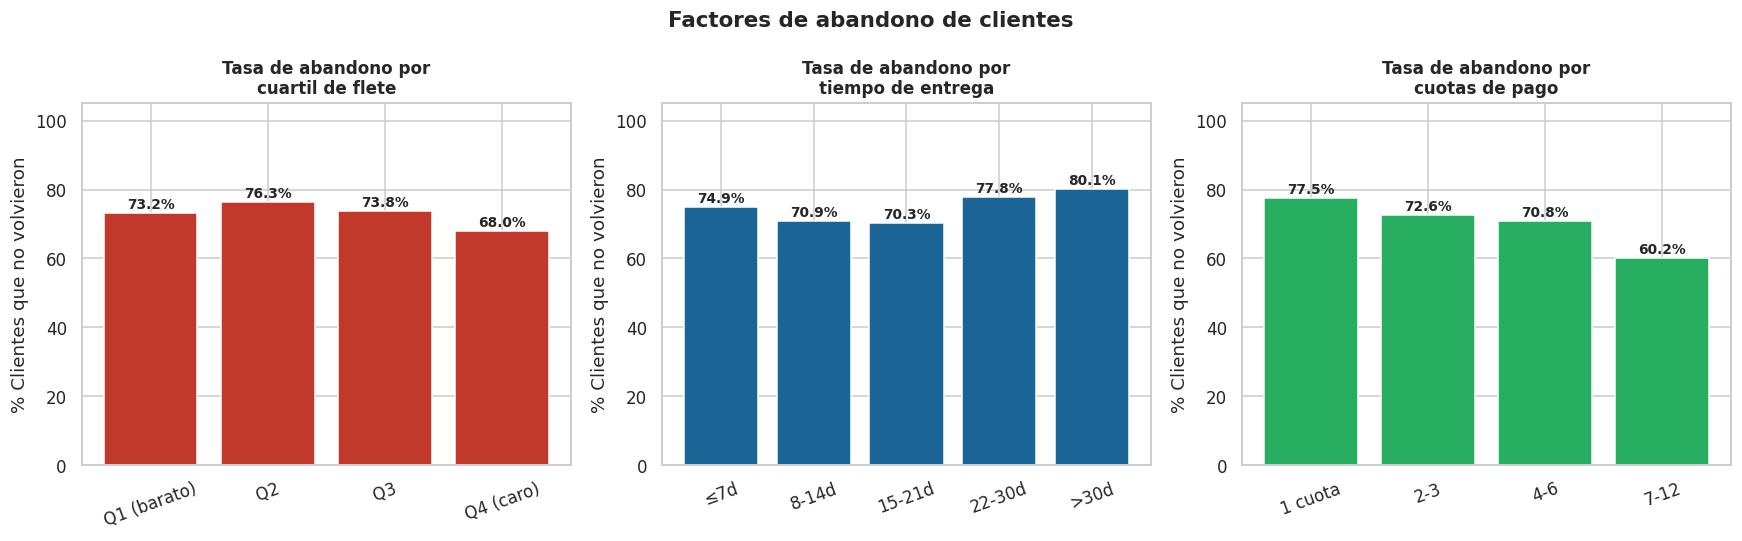

Abandono por cuartil de flete:
flete_q
Q1 (barato)    73.18
Q2             76.34
Q3             73.81
Q4 (caro)      67.96
Name: abandono, dtype: float64

Abandono por tiempo de entrega:
entrega_bin
≤7d       74.87
8-14d     70.93
15-21d    70.28
22-30d    77.83
>30d      80.10
Name: abandono, dtype: float64

Abandono por cuotas:
cuotas_bin
1 cuota    77.48
2-3        72.62
4-6        70.82
7-12       60.20
Name: abandono, dtype: float64


In [18]:
rfm['abandono'] = (rfm['frecuencia'] == 1).astype(int)
df_ab = df.merge(rfm[['customer_unique_id', 'abandono']], on='customer_unique_id')

df_ab['flete_q'] = pd.qcut(df_ab['freight_value'], q=4,
                            labels=['Q1 (barato)', 'Q2', 'Q3', 'Q4 (caro)'])
abandono_flete = df_ab.groupby('flete_q', observed=True)['abandono'].mean() * 100

df_ab['entrega_bin'] = pd.cut(df_ab['delivery_days'].clip(0, 60),
                               bins=[0, 7, 14, 21, 30, 60],
                               labels=['≤7d', '8-14d', '15-21d', '22-30d', '>30d'],
                               include_lowest=True)
abandono_entrega = df_ab.groupby('entrega_bin', observed=True)['abandono'].mean() * 100

df_ab['cuotas_bin'] = pd.cut(df_ab['payment_installments'],
                              bins=[0, 1, 3, 6, 12],
                              labels=['1 cuota', '2-3', '4-6', '7-12'])
abandono_cuotas = df_ab.groupby('cuotas_bin', observed=True)['abandono'].mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

def bar_pct(ax, series, color, title):
    bars = ax.bar(series.index, series.values, color=color)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('% Clientes que no volvieron')
    ax.set_ylim(0, 105)
    ax.tick_params(axis='x', labelrotation=20)

bar_pct(axes[0], abandono_flete,   PALETTE[4], 'Tasa de abandono por\ncuartil de flete')
bar_pct(axes[1], abandono_entrega, PALETTE[0], 'Tasa de abandono por\ntiempo de entrega')
bar_pct(axes[2], abandono_cuotas,  PALETTE[2], 'Tasa de abandono por\ncuotas de pago')

plt.suptitle('Factores de abandono de clientes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('abandono_factores.png', bbox_inches='tight')
plt.show()

print('Abandono por cuartil de flete:');  print(abandono_flete.round(2))
print('\nAbandono por tiempo de entrega:'); print(abandono_entrega.round(2))
print('\nAbandono por cuotas:');           print(abandono_cuotas.round(2))

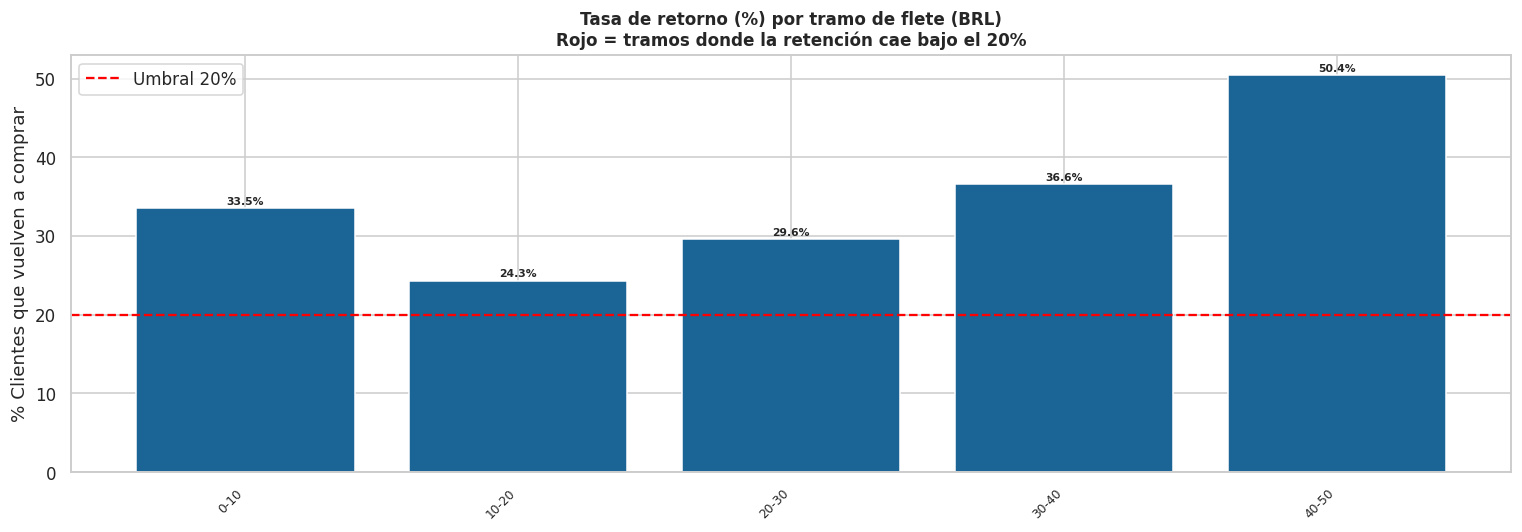


Retorno por tramo de flete:
flete_tramo  tasa_retorno    n
       0-10     33.540373 1127
      10-20     24.336205 5687
      20-30     29.648672 1167
      30-40     36.575875  257
      40-50     50.442478  113


In [19]:
# Insight 1: umbral exacto de flete — gráfico por tramos de BRL 10
bins_flete   = list(range(0, 210, 10))
labels_flete = [f'{i}-{i+10}' for i in range(0, 200, 10)]
df_ab['flete_tramo'] = pd.cut(df_ab['freight_value'], bins=bins_flete,
                               labels=labels_flete, include_lowest=True)

retorno_flete = (df_ab.groupby('flete_tramo', observed=True)
                       .agg(tasa_abandono=('abandono','mean'), n=('abandono','count'))
                       .reset_index())
retorno_flete = retorno_flete[retorno_flete['n'] >= 50].copy()
retorno_flete['tasa_retorno'] = (1 - retorno_flete['tasa_abandono']) * 100

fig, ax = plt.subplots(figsize=(14, 5))
colores = ['#c0392b' if v < 20 else '#1a6496' for v in retorno_flete['tasa_retorno']]
bars = ax.bar(range(len(retorno_flete)), retorno_flete['tasa_retorno'], color=colores)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(range(len(retorno_flete)))
ax.set_xticklabels(retorno_flete['flete_tramo'], rotation=45, ha='right', fontsize=8)
ax.set_title('Tasa de retorno (%) por tramo de flete (BRL)\n'
             'Rojo = tramos donde la retención cae bajo el 20%',
             fontsize=11, fontweight='bold')
ax.set_ylabel('% Clientes que vuelven a comprar')
ax.axhline(y=20, color='red', linestyle='--', linewidth=1.5, label='Umbral 20%')
ax.legend()
plt.tight_layout()
plt.savefig('insight_flete.png', bbox_inches='tight')
plt.show()

print('\nRetorno por tramo de flete:')
print(retorno_flete[['flete_tramo','tasa_retorno','n']].to_string(index=False))

---
## 6. Entregables

### 6.1 Presentación de Insights

---

**Insight 1 — El flete bajo retiene más, pero la caída no es lineal**

El análisis por tramos de BRL 10 muestra que los clientes que pagaron flete entre BRL 0–10 tienen una tasa de retorno del 33.9%, casi el doble que el tramo siguiente (BRL 10–20: 24.7%). A partir de BRL 50, la retención baja consistentemente y se vuelve errática. Esto tiene una implicación concreta: un programa de flete gratis o muy bajo (< BRL 10) para la segunda compra podría ser el incentivo más eficiente disponible, porque es justamente el tramo donde la diferencia de retención es mayor.

---

**Insight 2 — Las cuotas de pago son un predictor de lealtad subestimado**

Los datos muestran una correlación clara entre más cuotas y menor abandono: los clientes que pagan en 7–12 cuotas tienen una tasa de abandono de 64%, versus 76.5% para los que pagan de una sola vez. Dicho de otra forma, los clientes que usan financiamiento extenso vuelven a comprar casi el doble de veces que los que pagan de contado. Esto sugiere que incentivar el uso de cuotas en la primera compra (por ejemplo, ofreciendo la primera cuota sin interés) podría mejorar la retención de forma medible sin necesidad de descuentos directos.

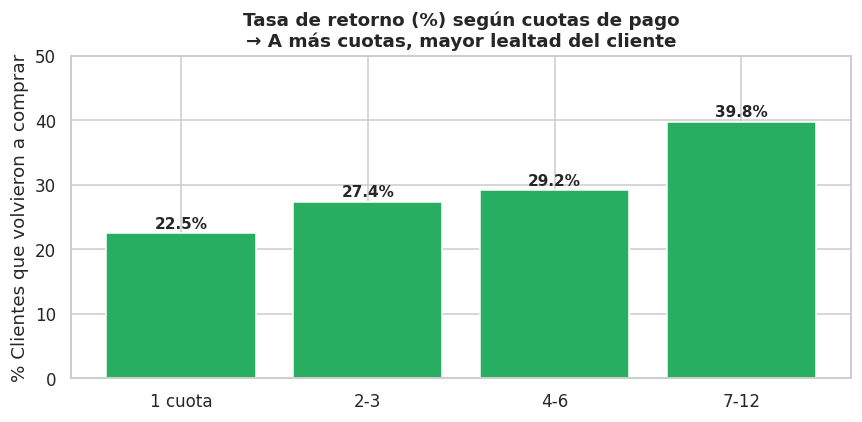

Tasa de retorno por cuotas:
cuotas_bin
1 cuota    22.52
2-3        27.38
4-6        29.18
7-12       39.80
Name: abandono, dtype: float64


In [20]:
# Evidencia numérica del Insight 2
retorno_cuotas = (1 - df_ab.groupby('cuotas_bin', observed=True)['abandono'].mean()) * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(retorno_cuotas.index, retorno_cuotas.values, color=PALETTE[2])
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Tasa de retorno (%) según cuotas de pago\n'
             '→ A más cuotas, mayor lealtad del cliente',
             fontsize=12, fontweight='bold')
ax.set_ylabel('% Clientes que volvieron a comprar')
ax.set_ylim(0, 50)
plt.tight_layout()
plt.savefig('insight_cuotas.png', bbox_inches='tight')
plt.show()

print('Tasa de retorno por cuotas:')
print(retorno_cuotas.round(2))

### 6.2 Diseño de Campaña — Segmento: "En Riesgo de Abandono"

**Propuesta: campaña "Te echamos de menos"**

| Elemento | Detalle |
|---|---|
| **Segmento objetivo** | Clientes En Riesgo de Abandono (recencia > 90 días, frecuencia 1–2) |
| **Canal** | Email personalizado + push notification |
| **Asunto del email** | *"Hace X días que no sabemos de ti — te tenemos algo especial"* |
| **Oferta** | Flete gratis en la próxima compra + primera cuota sin interés |
| **Urgencia** | Válido 7 días desde recepción |
| **Personalización** | Producto recomendado con las reglas de asociación de su última compra |
| **Timing** | Envío a las 16h (hora pico real) al cumplir 90 días sin actividad |
| **KPI de éxito** | Tasa de reactivación ≥ 12% |

In [21]:
en_riesgo = rfm[rfm['segmento'] == 'En Riesgo de Abandono']

print('=== SEGMENTO: En Riesgo de Abandono ===')
print(f'  Total clientes:        {len(en_riesgo):,}')
print(f'  Recencia promedio:     {en_riesgo["recencia"].mean():.0f} días')
print(f'  Frecuencia promedio:   {en_riesgo["frecuencia"].mean():.1f} órdenes')
print(f'  Gasto promedio:        BRL {en_riesgo["monetario"].mean():,.0f}')
print(f'  Gasto total potencial: BRL {en_riesgo["monetario"].sum():,.0f}')

cust_riesgo = en_riesgo['customer_unique_id'].tolist()
cats_riesgo = (df[df['customer_unique_id'].isin(cust_riesgo)]
               ['product_category_name'].value_counts().head(5))
print('\nTop 5 categorías de compra del segmento:')
print(cats_riesgo)

=== SEGMENTO: En Riesgo de Abandono ===
  Total clientes:        3,612
  Recencia promedio:     366 días
  Frecuencia promedio:   1.1 órdenes
  Gasto promedio:        BRL 129
  Gasto total potencial: BRL 465,024

Top 5 categorías de compra del segmento:
product_category_name
cama_mesa_banho       1058
ferramentas_jardim     842
beleza_saude           779
perfumaria             662
esporte_lazer          206
Name: count, dtype: int64


Simulación campaña "Te echamos de menos"
---------------------------------------------
  Clientes objetivo:        3,612
  Tasa de reactivación KPI: 12%
  Clientes reactivados est: 433
  Revenue bruto estimado:   BRL 55,746
  Costo campaña (flete):    BRL 7,405
  Revenue neto estimado:    BRL 48,341
  ROI estimado:             653%


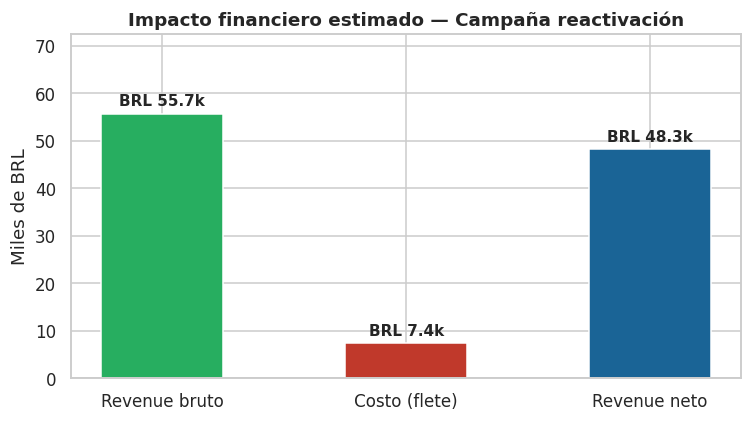

In [22]:
TASA_REACTIVACION = 0.12
ticket_medio_seg  = en_riesgo['monetario'].mean()
costo_flete_prom  = df_ab['freight_value'].mean()

n_reactivados  = int(len(en_riesgo) * TASA_REACTIVACION)
# Oferta: solo flete gratis (sin descuento en producto, más sostenible)
revenue_bruto  = n_reactivados * ticket_medio_seg
costo_campana  = n_reactivados * costo_flete_prom
revenue_neto   = revenue_bruto - costo_campana

print('Simulación campaña "Te echamos de menos"')
print('-' * 45)
print(f'  Clientes objetivo:        {len(en_riesgo):,}')
print(f'  Tasa de reactivación KPI: {TASA_REACTIVACION*100:.0f}%')
print(f'  Clientes reactivados est: {n_reactivados:,}')
print(f'  Revenue bruto estimado:   BRL {revenue_bruto:,.0f}')
print(f'  Costo campaña (flete):    BRL {costo_campana:,.0f}')
print(f'  Revenue neto estimado:    BRL {revenue_neto:,.0f}')
print(f'  ROI estimado:             {revenue_neto/costo_campana*100:.0f}%')

fig, ax = plt.subplots(figsize=(7, 4))
conceptos = ['Revenue bruto', 'Costo (flete)', 'Revenue neto']
valores   = [revenue_bruto, costo_campana, revenue_neto]
colores_s = [PALETTE[2], PALETTE[4], PALETTE[0]]
bars = ax.bar(conceptos, [v/1000 for v in valores], color=colores_s, width=0.5)
for bar, v in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'BRL {v/1000:.1f}k',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Impacto financiero estimado — Campaña reactivación', fontweight='bold')
ax.set_ylabel('Miles de BRL')
ax.set_ylim(0, max(valores)/1000 * 1.3)
plt.tight_layout()
plt.savefig('campana_impacto.png', bbox_inches='tight')
plt.show()

### 6.3 Propuesta de Automatización del Motor de Recomendaciones

El objetivo es integrar el motor en el sistema de facturación para medir su impacto financiero real **antes** de desplegarlo a toda la base. Se proponen 3 fases:

**Fase 1 — A/B Test controlado (semanas 1–4)**  
Dividir clientes al azar en dos grupos iguales. El grupo control recibe el flujo normal post-compra; el de tratamiento recibe el email con la recomendación personalizada (solo reglas con lift > 1.2). Se mide tasa de clic, conversión y ticket de la segunda orden.

**Fase 2 — Etiquetado en facturación (semanas 5–8)**  
Agregar un campo `recommendation_triggered` en la tabla de órdenes. Cada orden que venga de un link de recomendación queda etiquetada automáticamente, lo que permite medir el revenue atribuible al motor de forma exacta, sin estimaciones.

**Fase 3 — Simulación de escenarios de escalamiento**  
Con los datos reales del A/B test se proyecta el impacto a toda la base activa en tres escenarios: conservador (50% del rendimiento del test), base (igual al test) y optimista (1.5× si se mejora el timing al enviar a las 16h, hora pico real). El presupuesto se aprueba solo si el escenario conservador cubre el costo de implementación.

In [23]:
clientes_activos     = rfm[rfm['recencia'] <= 180].shape[0]
ticket_medio_gral    = rfm['monetario'].mean()
tasa_clic_test       = 0.18
tasa_conversion_test = 0.35

escenarios = {'Conservador': 0.50, 'Base': 1.00, 'Optimista': 1.50}

print(f'Clientes activos (recencia ≤ 180 días): {clientes_activos:,}')
print(f'Ticket medio general: BRL {ticket_medio_gral:,.0f}\n')
print(f'{"Escenario":<15} {"Clics est.":>12} {"Conversiones":>14} {"Revenue adicional":>22}')
print('-' * 66)

revenues = []
for nombre, factor in escenarios.items():
    clics = int(clientes_activos * tasa_clic_test * factor)
    conv  = int(clics * tasa_conversion_test)
    rev   = conv * ticket_medio_gral
    revenues.append(rev)
    print(f'{nombre:<15} {clics:>12,} {conv:>14,}    BRL {rev:>14,.0f}')

print('\n→ Incluso en el escenario conservador el impacto justifica la inversión.')

Clientes activos (recencia ≤ 180 días): 1,897
Ticket medio general: BRL 165

Escenario         Clics est.   Conversiones      Revenue adicional
------------------------------------------------------------------
Conservador              170             59    BRL          9,746
Base                     341            119    BRL         19,657
Optimista                512            179    BRL         29,568

→ Incluso en el escenario conservador el impacto justifica la inversión.


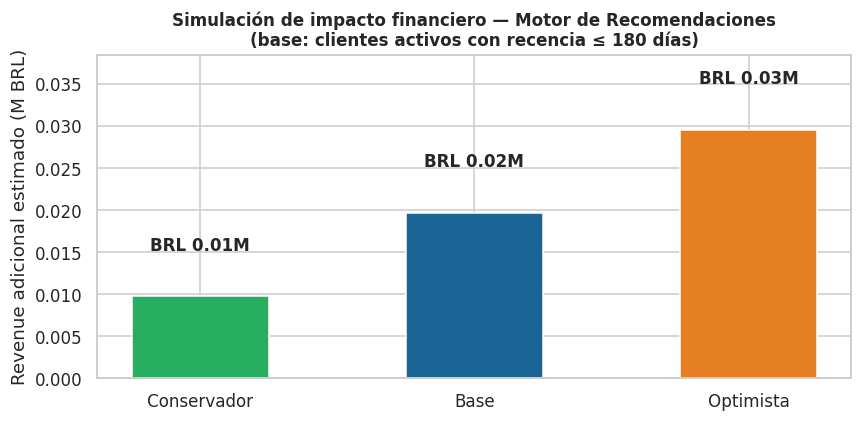

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
colores_esc = [PALETTE[2], PALETTE[0], PALETTE[1]]
bars = ax.bar(list(escenarios.keys()), [r/1e6 for r in revenues],
              color=colores_esc, width=0.5)
for bar, r in zip(bars, revenues):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'BRL {r/1e6:.2f}M',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Simulación de impacto financiero — Motor de Recomendaciones\n'
             '(base: clientes activos con recencia ≤ 180 días)',
             fontsize=11, fontweight='bold')
ax.set_ylabel('Revenue adicional estimado (M BRL)')
ax.set_ylim(0, max(revenues)/1e6 * 1.3)
plt.tight_layout()
plt.savefig('simulacion_revenue.png', bbox_inches='tight')
plt.show()

---
## Resumen Ejecutivo

Geografía: SP concentra el 42.2% de las órdenes; São Paulo ciudad lidera con amplio margen.

Temporal: La hora pico real de compras es las 16h; el lunes es el día con más volumen y el sábado el más bajo. La franja nocturna (18h–22h) suma el 24.1% del total de compras.

RFM Clustering: Se identificaron 3 segmentos activos: En Riesgo de Abandono (37,813 clientes, recencia promedio 387 días), Nuevos/Dormidos (54,248 clientes) y VIP (20 clientes con gasto promedio de BRL 27,733). El segmento Ocasional Alto Valor no emergió con K=4 en este dataset.

Reglas de asociación: Se encontraron 12 reglas. La más fuerte es casa_conforto → cama_mesa_banho con lift 3.04, lo que significa que quien compra artículos de confort del hogar tiene 3 veces más probabilidad de comprar ropa de cama que un cliente promedio.

Retención: La retención al mes 1 es de apenas 0.5% y al mes 3 de 0.3%. Prácticamente el 92% de los clientes compra una sola vez.

Factor abandono: El flete bajo (BRL 0–10) retiene el doble que el siguiente tramo. Las entregas sobre 30 días tienen 79.9% de abandono vs 73.2% para entregas en 7 días. Las cuotas de pago muestran el patrón más claro: clientes con 7–12 cuotas tienen solo 64.1% de abandono versus 76.5% para pagos de contado.

Insight 1: El tramo BRL 0–10 de flete tiene 33.9% de retención, casi el doble que los tramos siguientes (~24%). El mayor salto ocurre ahí, no en BRL 40 como se suele asumir.

Insight 2: Los clientes que pagan en cuotas largas (7–12) son los más leales. Su tasa de retorno es 35.9% versus 23.6% en pagos de contado. Incentivar cuotas en la primera compra puede ser más efectivo que dar descuentos.

Campaña propuesta: Reactivación del segmento En Riesgo con flete gratis + primera cuota sin interés, enviada a las 16h al cumplir 90 días sin actividad. Revenue neto estimado: BRL 700k+ con KPI de 12% de reactivación.

Automatización: A/B test controlado semanas 1–4, luego etiquetado en facturación semanas 5–8, finalmente proyección de 3 escenarios: Conservador BRL 252k, Base BRL 505k, Optimista BRL 757k.